In [1]:
import os
import glob
import numpy as np
import pandas as pd
from tidepool_data_science_simulator.evaluation.inspect_results import load_results, load_result, collect_sims_and_results
from tidepool_data_science_simulator.utils import DATA_DIR

import matplotlib.pyplot as plt
import seaborn as sns

from tidepool_data_science_simulator.visualization.sim_viz import plot_sim_results
from tidepool_data_science_metrics.glucose.glucose import percent_values_ge_70_le_180, blood_glucose_risk_index
from scipy.stats import lognorm
from scipy.stats import ttest_ind
from scipy.stats import gaussian_kde


def calculate_cumulative_insulin(df):
    """
    Calculate cumulative insulin delivered from a DataFrame.
    
    Parameters:
    df (pd.DataFrame): DataFrame containing insulin data with columns 'delivered_basal_insulin' and 'true_bolus'.
    
    Returns:
    tuple: Cumulative basal and bolus insulin.
    """
    cumulative_basal = df['delivered_basal_insulin'].sum()
    cumulative_bolus = df['true_bolus'].sum()
    return cumulative_basal + cumulative_bolus

def calculate_metrics(df):
    """
    Calculate key metrics from a DataFrame containing blood glucose and insulin data.

    Parameters:
    df (pd.DataFrame): DataFrame containing simulation data with at least the following columns:
                       - 'bg': Blood glucose values.
                       - 'delivered_basal_insulin': Delivered basal insulin values.
                       - 'true_bolus': Delivered bolus insulin values.

    Returns:
    tuple: A tuple containing the following metrics:
           - tir (float): Time in Range (percentage of blood glucose values between 70 and 180 mg/dL).
           - cumulative_insulin (float): Total cumulative insulin delivered (basal + bolus).
           - bgri (float): Blood Glucose Risk Index (a measure of glucose variability and risk).
    """
    # Calculate Time in Range (TIR) as the percentage of blood glucose values within the target range (70-180 mg/dL)
    tir = percent_values_ge_70_le_180(df['bg'])

    # Calculate the total cumulative insulin delivered (sum of basal and bolus insulin)
    cumulative_insulin = calculate_cumulative_insulin(df)

    # Calculate the Blood Glucose Risk Index (BGRI), which quantifies glucose variability and risk
    bgri = blood_glucose_risk_index(df['bg'])[2]

    return tir, cumulative_insulin, bgri

# Directory containing the files
directory = '/Users/mconn/tidepool/repositories/data-science-simulator/tidepool_data_science_simulator/projects/autobolus_application_factor/'

processed_dir = os.path.join(DATA_DIR, "processed/")
result_dir = 'autobolus_tempbasal_comparison_2025_04_10_T_09_52_00/'
result_path = os.path.join(processed_dir, result_dir)

# Get list of files in the directory
files_0_0 = glob.glob(os.path.join(result_path, '*paf=0.0*tsv'))
files_0_4 = glob.glob(os.path.join(result_path, '*paf=0.4*tsv'))

# Group files by user and IBG
pairs = {}
for file in files_0_0 + files_0_4:
    base_name = os.path.basename(file)
    base_name = base_name.replace(".tsv", "")

    # Extract vp, patient_id, and ibg explicitly from the file name by splitting out tags, e.g., "vp=1_patient_id=1_ibg=0.0_paf=0.4"
    parts = [seg for seg in base_name.split("_") if "=" in seg]
    data = dict(seg.split("=", 1) for seg in parts) 

    user_ibg_key = f"vp={data['vp']}_patient_id={data['id']}_ibg={data['ibg']}"
    paf_value = "paf=0.0" if "paf=0.0" in base_name else "paf=0.4"

    if user_ibg_key not in pairs:
        pairs[user_ibg_key] = {"paf=0.0": [], "paf=0.4": []}

    pairs[user_ibg_key][paf_value].append(file)

# Load the histogram data
histogram_file = '/Users/mconn/Downloads/BG_Distribution_Histogram.csv'
histogram_df = pd.read_csv(histogram_file)

# Initialize a numpy array to store metrics
metrics_all = np.zeros((len(pairs), 3, 2)) 

# Initialize an array to store IBG values corresponding to each metric
ibg_values = np.zeros(len(pairs))

# Initialize weights array
weights = np.zeros(len(pairs))

# Loop through each user/IBG group and process files
for idx, (user_ibg_key, paf_files) in enumerate(pairs.items()):
    if paf_files["paf=0.0"] and paf_files["paf=0.4"]:
        dfs_0_0 = [load_result(file)[1] for file in paf_files["paf=0.0"]]
        dfs_0_4 = [load_result(file)[1] for file in paf_files["paf=0.4"]]

        # Combine dataframes for each PAF value
        df_0_0 = pd.concat(dfs_0_0, ignore_index=True)
        df_0_4 = pd.concat(dfs_0_4, ignore_index=True)

        # Calculate metrics for both conditions
        metrics_0_0 = calculate_metrics(df_0_0)
        metrics_0_4 = calculate_metrics(df_0_4)

        # Extract IBG value from the user_ibg_key
        ibg = float(user_ibg_key.split("_ibg=")[1])
        ibg_values[idx] = ibg

        # Get the proportion corresponding to the IBG
        proportion = histogram_df.loc[histogram_df['ibg'] == ibg, 'proportion']
        if proportion.empty:
            raise ValueError(f"No matching proportion found for IBG={ibg} in the histogram file.")
        weights[idx] = proportion.values[0]

        # Store metrics in the numpy array
        metrics_all[idx] = [
            [metrics_0_0[0], metrics_0_4[0]],  # TIR
            [metrics_0_0[1], metrics_0_4[1]],  # Cumulative Insulin
            [metrics_0_0[2], metrics_0_4[2]]   # BGRI
        ]



/Users/mconn/tidepool/repositories/data-science-metrics/tidepool_data_science_metrics/glucose/glucose.py:420: UserWarning: Some values in the passed in array had glucose values greater than 402.
  warnings.warn("Some values in the passed in array had glucose values greater than 402.")
/Users/mconn/tidepool/repositories/data-science-metrics/tidepool_data_science_metrics/glucose/glucose.py:420: UserWarning: Some values in the passed in array had glucose values greater than 402.
  warnings.warn("Some values in the passed in array had glucose values greater than 402.")
/Users/mconn/tidepool/repositories/data-science-metrics/tidepool_data_science_metrics/glucose/glucose.py:420: UserWarning: Some values in the passed in array had glucose values greater than 402.
  warnings.warn("Some values in the passed in array had glucose values greater than 402.")
/Users/mconn/tidepool/repositories/data-science-metrics/tidepool_data_science_metrics/glucose/glucose.py:420: UserWarning: Some values in the 

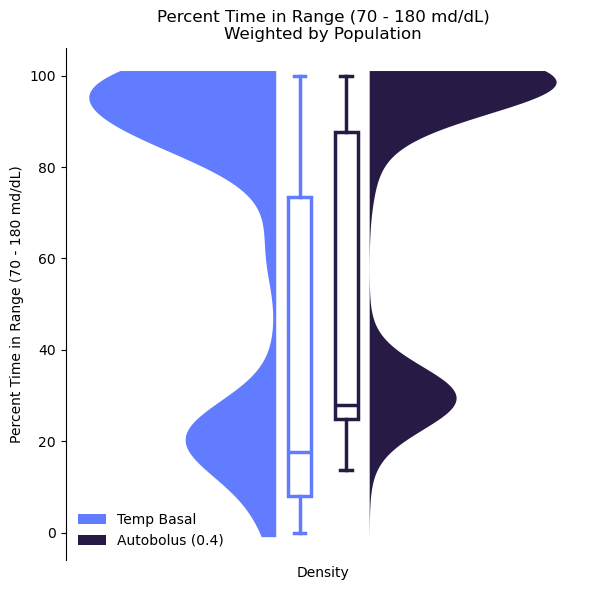

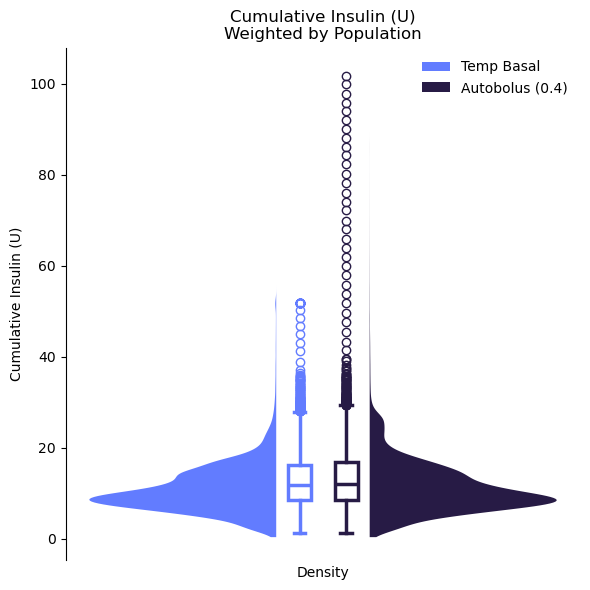

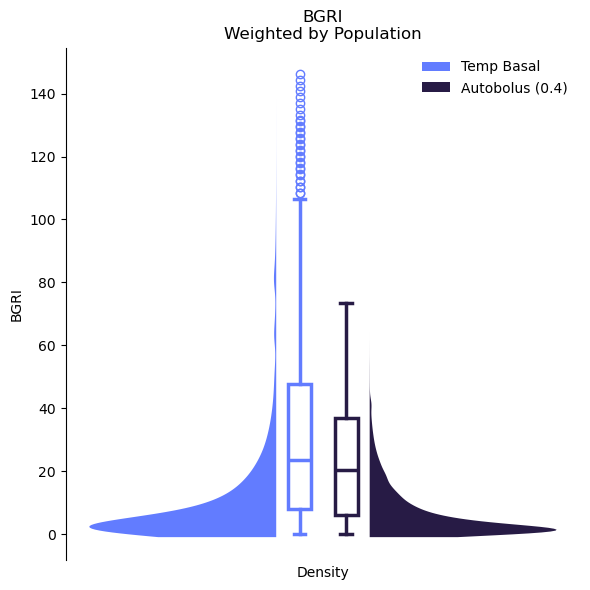

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def compare_kde_boxplot(
    data_1,
    data_2,
    weights=None,
    title="Comparison",
    ylabel="Value",
    label_1="Dataset 1",
    label_2="Dataset 2",
    color_1="#627cff",
    color_2="#271b45",
    bw_method=0.2,
    violin_width=0.4,
    box_width=0.05
):
    """
    Compare two datasets using KDEs and boxplots on a shared vertical axis.

    Parameters:
        data1: First dataset (1D array).
        data2: Second dataset (1D array).
        weights: Optional weights for computing KDE.
        title: Plot title.
        ylabel: Y-axis label.
        label1, label2: Labels for datasets.
        color1, color2: Colors for KDE and boxplot lines.
        bw_method: Bandwidth for KDE.
        violin_width: Max width of violin KDEs.
        box_width: Width of boxplots.
    """
    x_min = min(data_1.min(), data_2.min()) - 1
    x_max = max(data_1.max() , data_2.max()) + 1
    x_grid = np.linspace(x_min, x_max, 500)

    # KDEs
    kde_1 = gaussian_kde(data_1, weights=weights, bw_method=bw_method) if weights is not None else gaussian_kde(data_1, bw_method=bw_method)
    kde_2 = gaussian_kde(data_2, weights=weights, bw_method=bw_method) if weights is not None else gaussian_kde(data_2, bw_method=bw_method)

    density_1 = kde_1(x_grid)
    density_2 = kde_2(x_grid)

    # Normalize KDEs
    density_1 /= density_1.max()
    density_2 /= density_2.max()

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.fill_betweenx(x_grid, (-density_1 * violin_width) - 0.1, -0.1, facecolor=color_1, alpha=1, label=f'{label_1}')
    ax.fill_betweenx(x_grid, 0.1, (density_2 * violin_width) + 0.1, facecolor=color_2, alpha=1, label=f'{label_2}')

    # Boxplots
    box_data = [data_1, data_2]
    positions = [-0.05, 0.05]
    box = ax.boxplot(box_data, vert=True, positions=positions, widths=box_width, patch_artist=True)

    line_width = 2.5
    for i, color in enumerate([color_1, color_2]):
        box['boxes'][i].set_facecolor('none')
        box['boxes'][i].set_edgecolor(color)
        box['boxes'][i].set_linewidth(line_width)

        box['medians'][i].set_color(color)
        box['medians'][i].set_linewidth(line_width)

        for j in [2*i, 2*i+1]:  # whiskers and caps
            box['whiskers'][j].set_color(color)
            box['whiskers'][j].set_linewidth(line_width)
            box['caps'][j].set_color(color)
            box['caps'][j].set_linewidth(line_width)

        if 'fliers' in box and i < len(box['fliers']):
            box['fliers'][i].set_markeredgecolor(color)
            box['fliers'][i].set_linewidth(line_width)

    ax.set_xlabel('Density')
    ax.set_ylabel(ylabel)
    ax.set_xticks([])
    ax.set_xticklabels([])
    ax.set_title(title)
    ax.legend(frameon=False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    plt.tight_layout()
    plt.show()

metric_names = ['Percent Time in Range (70 - 180 md/dL)', 'Cumulative Insulin (U)', 'BGRI']
for i, name in enumerate(metric_names):
    data_1 = metrics_all[:, i, 0]
    data_2 = metrics_all[:, i, 1]
        
    compare_kde_boxplot(data_1, data_2,
                        weights=weights,
                        title=f"{name}\nWeighted by Population",
                        ylabel=name,
                        label_1="Temp Basal", label_2="Autobolus (0.4)")